# ECON 3385 - Problem Set 8

Anton Melnychuk

In [1]:
import pandas as pd
import numpy as np
from linearmodels.iv import IV2SLS
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

### Data Summary

The dataset covers business jets sold by 6 leading manufacturers from 1961 to 2000. Each observation is at the manufacturer–year–segment level, with at most one product per manufacturer per segment. The three segments — Small (S), Medium (M), and Large (L) — capture different tiers of the market. We treat each (year, segment) pair as a separate market.

In [2]:
df = pd.read_csv('jets.csv')
df = df.sort_values(['year', 'segment', 'manuf']).reset_index(drop=True)

print(f'Observations : {len(df)}')
print(f'Years        : {df.year.min()} – {df.year.max()}')
print(f'Manufacturers: {sorted(df.manuf.unique())}')
print(f'Segments     : {sorted(df.segment.unique())}')
print()
print(df[['purchases', 'range', 'vol', 'speed', 'noise', 'price']].describe().round(2))

Observations : 341
Years        : 1961 – 2000
Manufacturers: ['Bombardier', 'Cessna', 'Dassault', 'Gulfstream', 'IAI', 'Other', 'Raytheon']
Segments     : ['L', 'M', 'S']

       purchases    range      vol   speed   noise   price
count    341.000  341.000  341.000 341.000 341.000 341.000
mean      22.360 2528.860  613.360 463.670  83.220  14.570
std       23.030  916.130  382.030  31.930   5.240  11.150
min        1.000 1266.000  205.000 357.000  70.800   0.800
25%        8.000 1780.000  305.000 460.000  79.800   6.640
50%       16.000 2340.390  453.000 468.600  82.120  10.280
75%       27.000 3081.400  700.000 479.500  87.000  20.500
max      158.000 5522.860 1607.290 505.000  94.490  53.630


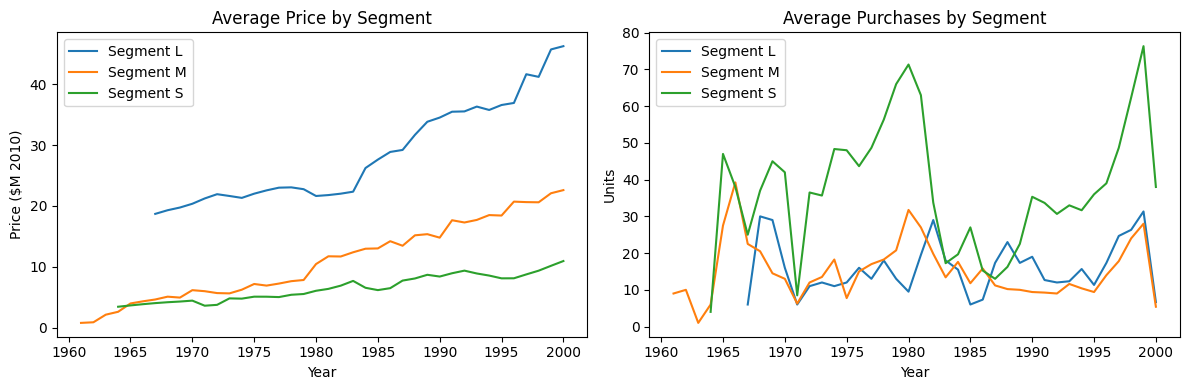

In [3]:
# Average price and purchases by segment over time
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for seg, grp in df.groupby('segment'):
    ann = grp.groupby('year')[['price', 'purchases']].mean()
    axes[0].plot(ann.index, ann['price'],   label=f'Segment {seg}')
    axes[1].plot(ann.index, ann['purchases'], label=f'Segment {seg}')
axes[0].set(title='Average Price by Segment', xlabel='Year', ylabel='Price ($M 2010)')
axes[1].set(title='Average Purchases by Segment', xlabel='Year', ylabel='Units')
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

### Demand Model

We estimate a logit demand model following Berry (1994). Consumer $i$ derives utility from jet $j$ in market $t$ (year × segment):

$$u_{ijt} = \underbrace{\beta_j + \beta_{\text{range}} \cdot \text{range}_j + \beta_{\text{vol}} \cdot \text{vol}_j + \beta_{\text{speed}} \cdot \text{speed}_j}_{\delta_{jt}} + \alpha p_{jt} + \varepsilon_{ijt}$$

where $\varepsilon_{ijt} \sim$ Type I Extreme Value. Berry's inversion gives the linear estimating equation:

$$\ln s_{jt} - \ln s_{0t} = \delta_{jt} + \alpha p_{jt} + \xi_{jt}$$

**Endogeneity:** Price is endogenous because unobserved quality $\xi_{jt}$ is correlated with price. We instrument using **BLP instruments**: for each product $j$ in market $t$, the sum of characteristics of rival products in the same market shifts competitors' marginal costs (and hence prices) without directly entering $j$'s utility. We also include the number of rivals.

In [4]:
# ── Market shares ──────────────────────────────────────────────────────────
df['share'] = df['purchases'] / df['market_size']
df['mkt_share_total'] = df.groupby(['year', 'segment'])['share'].transform('sum')
df['outside_share']   = 1 - df['mkt_share_total']
df = df[df['outside_share'] > 0].reset_index(drop=True)
df['y'] = np.log(df['share']) - np.log(df['outside_share'])   # Berry LHS

# ── BLP instruments ────────────────────────────────────────────────────────
for char in ['range', 'vol', 'speed']:
    mkt_sum          = df.groupby(['year', 'segment'])[char].transform('sum')
    df[f'z_{char}']  = mkt_sum - df[char]   # sum of rivals' characteristic
df['n_rivals'] = df.groupby(['year', 'segment'])['manuf'].transform('count') - 1

print(f'Monopoly markets (z_range==0): {(df.z_range==0).sum()} / {len(df)}')
print(df[['share', 'outside_share', 'y', 'z_range']].describe().round(3))

Monopoly markets (z_range==0): 22 / 341
        share  outside_share       y   z_range
count 341.000        341.000 341.000   341.000
mean    0.005          0.984  -5.993  6608.917
std     0.008          0.021   1.242  3483.527
min     0.000          0.862  -9.276     0.000
25%     0.001          0.981  -6.792  3676.853
50%     0.002          0.991  -6.108  6011.791
75%     0.005          0.994  -5.268 10205.464
max     0.051          0.999  -2.915 12449.819


In [5]:
# ── IV2SLS estimation ──────────────────────────────────────────────────────
manuf_dum = pd.get_dummies(df['manuf'],   prefix='m', drop_first=True, dtype=float)
seg_dum   = pd.get_dummies(df['segment'], prefix='s', drop_first=True, dtype=float)

X_exog  = pd.concat([pd.Series(1.0, index=df.index, name='const'),
                     df[['range', 'vol', 'speed']], manuf_dum, seg_dum], axis=1)
X_endog = df[['price']].astype(float)
Z       = df[['z_range', 'z_vol', 'z_speed', 'n_rivals']].astype(float)

result  = IV2SLS(df['y'], X_exog, X_endog, Z).fit(cov_type='robust')
print(result.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                      y   R-squared:                      0.4876
Estimator:                    IV-2SLS   Adj. R-squared:                 0.4689
No. Observations:                 341   F-statistic:                    369.75
Date:                Sun, Mar 29 2026   P-value (F-stat)                0.0000
Time:                        18:00:27   Distribution:                 chi2(12)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
const           -10.147     1.8033    -5.6267     0.0000     -13.681     -6.6122
range            0.0002     0.0002     0.819

In [6]:
gamma  = result.params['price']
params = result.params
print(f'Price coefficient α = {gamma:.4f}  (must be < 0)')
assert gamma < 0, 'Price coefficient should be negative'

# Structural components
df['fitted']     = result.fitted_values.values
df['xi']         = df['y'] - df['fitted']              # structural error
df['delta_base'] = df['y'] - gamma * df['price']       # Xβ + ξ  (non-price mean utility)

Price coefficient α = -0.1551  (must be < 0)


### Marginal Cost Recovery

Under Bertrand–Nash competition, each firm maximises profit over its portfolio. Because each manufacturer has **at most one product per (year, segment) market**, the within-market first-order condition simplifies to the single-product case:

$$s_j + (p_j - mc_j)\frac{\partial s_j}{\partial p_j} = 0$$

With logit demand $\partial s_j / \partial p_j = \alpha s_j(1-s_j)$, this gives:

$$mc_j = p_j + \frac{1}{\alpha(1 - s_j)}$$

Since $\alpha < 0$, marginal cost is below price. For **multi-product** equilibria (merger / entry counterfactuals), we use the full ownership matrix:

$$\mathbf{mc} = \mathbf{p} - \Delta^{-1}\mathbf{s}, \qquad \Delta_{jk} = -\frac{\partial s_k}{\partial p_j}\cdot \mathbf{1}[\text{same firm}]$$

In [7]:
# Single-product Bertrand FOC (valid for original data)
df['mc']     = df['price'] + 1 / (gamma * (1 - df['share']))
df['margin'] = (df['price'] - df['mc']) / df['price']   # Lerner index

print('Marginal cost statistics:')
print(df[['price', 'mc', 'margin']].describe().round(3))
print(f'\nNegative MC observations: {(df.mc < 0).sum()} '
      f'(mainly early-year low-price jets; all year-2000 MCs are positive)')
print('\nYear 2000 products:')
print(df[df.year == 2000][['manuf','segment','price','mc','margin','share']].to_string(index=False))

Marginal cost statistics:
        price      mc  margin
count 341.000 341.000 341.000
mean   14.571   8.088   0.837
std    11.153  11.173   0.885
min     0.799  -5.999   0.121
25%     6.636   0.139   0.315
50%    10.279   3.818   0.629
75%    20.503  14.039   0.979
max    53.627  47.161   8.507

Negative MC observations: 82 (mainly early-year low-price jets; all year-2000 MCs are positive)

Year 2000 products:
     manuf segment  price     mc  margin  share
Bombardier       L 47.105 40.651   0.137  0.001
  Dassault       L 38.939 32.489   0.166  0.000
Gulfstream       L 52.667 46.216   0.122  0.000
Bombardier       M 16.531 10.080   0.390  0.000
    Cessna       M 21.601 15.149   0.299  0.001
  Dassault       M 29.158 22.708   0.221  0.000
       IAI       M 26.527 20.078   0.243  0.000
  Raytheon       M 19.183 12.732   0.336  0.000
Bombardier       S 12.585  6.125   0.513  0.002
    Cessna       S  9.011  2.525   0.720  0.006
  Raytheon       S 11.265  4.809   0.573  0.001


### Helper Functions — Equilibrium Solver

In [8]:
def solve_equilibrium(data, gamma, mc_arr, firm_col='firm',
                      p_init=None, max_iter=2000, tol=1e-10):
    """
    Solve Bertrand-Nash equilibrium via fixed-point iteration:
        p* = mc + Δ(p*)^{-1} s(p*)
    Works for multi-product firms within each (year, segment) market.
    """
    data  = data.reset_index(drop=True)
    n     = len(data)
    firms = np.array(data[firm_col].astype(str).tolist())
    db    = data['delta_base'].values.astype(float)
    p     = (data['price'].values.copy().astype(float)
             if p_init is None else p_init.astype(float))

    for _ in range(max_iter):
        # ── Logit shares ──
        delta = db + gamma * p
        s     = np.zeros(n)
        for (yr, seg), grp in data.groupby(['year', 'segment']):
            idx = grp.index.tolist()
            d   = delta[idx]
            ed  = np.exp(d)
            s[idx] = ed / (1 + ed.sum())

        # ── Bertrand FOC per market ──
        p_new = p.copy()
        for (yr, seg), grp in data.groupby(['year', 'segment']):
            idx = grp.index.tolist()
            m   = len(idx)
            sm  = s[idx]
            fm  = firms[idx]
            mcm = mc_arr[idx]
            Om  = (fm[:, None] == fm[None, :]).astype(float)
            Dm  = np.zeros((m, m))
            for a in range(m):
                for b in range(m):
                    Dm[a, b] = ((-gamma * sm[a] * (1 - sm[a])
                                 if a == b else
                                 gamma * sm[b] * sm[a]) * Om[a, b])
            try:
                p_new[idx] = mcm + np.linalg.solve(Dm, sm)
            except np.linalg.LinAlgError:
                pass

        if np.max(np.abs(p_new - p)) < tol:
            break
        p = p_new
    return p_new, s


def delta_base_new_product(seg, manuf, params, df_2000):
    """
    Compute delta_base (non-price mean utility) for a new product
    whose characteristics equal the segment average. ξ_new = 0.
    """
    seg_data = df_2000[df_2000['segment'] == seg]
    x  = params['const']
    x += params['range'] * seg_data['range'].mean()
    x += params['vol']   * seg_data['vol'].mean()
    x += params['speed'] * seg_data['speed'].mean()
    for col in [c for c in params.index if c.startswith('m_')]:
        x += params[col] * (1 if manuf == col.replace('m_', '') else 0)
    x += params['s_M'] * (1 if seg == 'M' else 0)
    x += params['s_S'] * (1 if seg == 'S' else 0)
    return x


def firm_profit(p, s, mc, firm_arr, firm_name, mkt_size):
    mask = np.array(firm_arr) == firm_name
    return float(np.sum((p[mask] - mc[mask]) * s[mask] * mkt_size))


print('Helper functions defined.')

Helper functions defined.


### Question 1 — Profit Margins Over Time

The Lerner index (profit margin) for product $j$ in year $t$ is:

$$L_{jt} = \frac{p_{jt} - mc_{jt}}{p_{jt}} = \frac{-1}{\alpha(1-s_{jt})p_{jt}}$$

We decompose changes in per-unit profits ($p - mc$) into a **price effect** ($\Delta p$) and a **cost effect** ($\Delta mc$):

$$\Delta(p - mc) = \Delta p - \Delta mc$$

In [9]:
# ── Firm-level annual averages ────────────────────────────────────────────
df_pos = df[df['mc'] > 0].copy()   # exclude implausible early-year negatives

firm_yr = (df_pos.groupby(['year', 'manuf'])
           .agg(avg_price=('price',  'mean'),
                avg_mc   =('mc',     'mean'),
                avg_margin=('margin','mean'),
                total_profit=('purchases', lambda x:
                              (( df_pos.loc[x.index,'price']
                               - df_pos.loc[x.index,'mc'])*x).sum()))
           .reset_index())

# Year-over-year decomposition per firm
firm_yr = firm_yr.sort_values(['manuf','year'])
firm_yr['d_price']  = firm_yr.groupby('manuf')['avg_price'].diff()
firm_yr['d_mc']     = firm_yr.groupby('manuf')['avg_mc'].diff()
firm_yr['d_margin_per_unit'] = firm_yr['d_price'] - firm_yr['d_mc']

print('Average margin by manufacturer (all years):')
print(firm_yr.groupby('manuf')['avg_margin'].mean().round(3).to_string())

Average margin by manufacturer (all years):
manuf
Bombardier   0.501
Cessna       0.566
Dassault     0.514
Gulfstream   0.228
IAI          0.495
Other        0.863
Raytheon     0.601


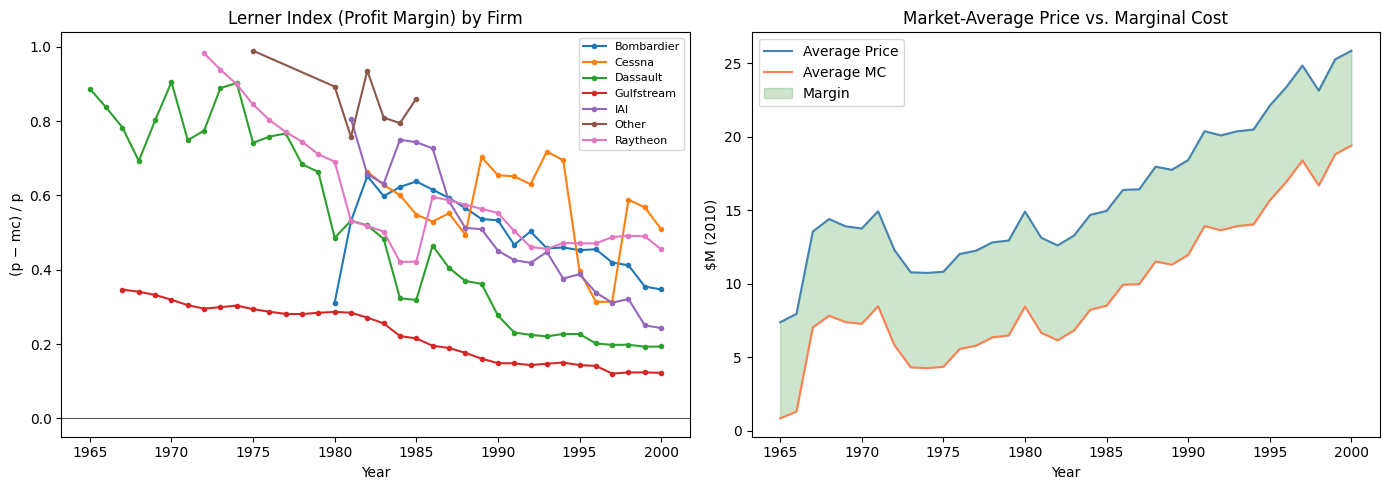

In [10]:
# ── Plot margins over time ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for manuf, grp in firm_yr.groupby('manuf'):
    axes[0].plot(grp['year'], grp['avg_margin'], label=manuf, marker='o', markersize=3)
axes[0].set(title='Lerner Index (Profit Margin) by Firm', xlabel='Year', ylabel='(p − mc) / p')
axes[0].legend(fontsize=8)
axes[0].axhline(0, color='k', linewidth=0.5)

# ── Plot price vs MC decomposition (market-level average) ─────────────────
market_avg = df_pos.groupby('year')[['price','mc']].mean()
axes[1].plot(market_avg.index, market_avg['price'], label='Average Price',  color='steelblue')
axes[1].plot(market_avg.index, market_avg['mc'],    label='Average MC',     color='coral')
axes[1].fill_between(market_avg.index, market_avg['mc'], market_avg['price'],
                     alpha=0.2, color='green', label='Margin')
axes[1].set(title='Market-Average Price vs. Marginal Cost', xlabel='Year', ylabel='$M (2010)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# ── Decomposition: price vs cost contribution to margin change ────────────
decomp = (firm_yr.dropna(subset=['d_price','d_mc'])
          .groupby('manuf')[['d_price','d_mc','d_margin_per_unit']]
          .mean().round(3))
decomp.columns = ['Avg Δprice','Avg Δmc','Avg Δmargin (=Δp−Δmc)']
print('Year-over-year decomposition of per-unit profit changes (averages):')
print(decomp.to_string())
print()
print('Interpretation: a positive Δprice increases margins; a positive Δmc reduces them.')

Year-over-year decomposition of per-unit profit changes (averages):
            Avg Δprice  Avg Δmc  Avg Δmargin (=Δp−Δmc)
manuf                                                 
Bombardier       0.234    0.234                  0.000
Cessna           0.311    0.309                  0.001
Dassault         0.762    0.765                 -0.003
Gulfstream       1.029    1.030                 -0.001
IAI              0.972    0.974                 -0.002
Other            0.159    0.163                 -0.004
Raytheon         0.308    0.309                 -0.001

Interpretation: a positive Δprice increases margins; a positive Δmc reduces them.


### Question 2 — Cessna–Bombardier Merger (Year 2000)

In year 2000, **Cessna and Bombardier both compete in the Small (S) and Medium (M) segments**. A merger internalises cross-price effects: the merged firm raises prices because it now accounts for the business it diverts to its sister brand rather than losing it to a rival.

We solve the post-merger Bertrand equilibrium by updating the ownership matrix and iterating to a fixed point. We then find the minimum cost reduction $\delta^*$ (applied uniformly to all Cessna and Bombardier products) such that post-merger prices do not exceed pre-merger prices — the **efficiency defense threshold**.

In [12]:
# ── Year 2000 baseline ────────────────────────────────────────────────────
d00        = df[df['year'] == 2000].copy().reset_index(drop=True)
d00['firm']= d00['manuf']
mc00       = d00['mc'].values
mkt_size   = int(d00['market_size'].values[0])

p_pre, s_pre = solve_equilibrium(d00, gamma, mc00, p_init=d00['price'].values.copy())
print('Pre-merger year 2000 equilibrium (observed ≈ solved):')
print(pd.DataFrame({'manuf': d00.manuf, 'seg': d00.segment,
                    'p_obs': d00.price.round(3), 'p_eq': p_pre.round(3),
                    'mc': mc00.round(3),
                    'margin%': ((p_pre-mc00)/p_pre*100).round(1)}).to_string(index=False))

Pre-merger year 2000 equilibrium (observed ≈ solved):
     manuf seg  p_obs   p_eq     mc  margin%
Bombardier   L 47.105 47.105 40.651   13.700
  Dassault   L 38.939 38.939 32.489   16.600
Gulfstream   L 52.667 52.667 46.216   12.200
Bombardier   M 16.531 16.531 10.080   39.000
    Cessna   M 21.601 21.601 15.149   29.900
  Dassault   M 29.158 29.158 22.708   22.100
       IAI   M 26.527 26.527 20.078   24.300
  Raytheon   M 19.183 19.183 12.732   33.600
Bombardier   S 12.585 12.585  6.125   51.300
    Cessna   S  9.011  9.011  2.525   72.000
  Raytheon   S 11.265 11.265  4.809   57.300


In [13]:
# ── Post-merger equilibrium (no efficiencies) ─────────────────────────────
d00m = d00.copy()
d00m['firm'] = d00m['manuf'].replace({'Cessna': 'CB', 'Bombardier': 'CB'})

p_post_no_eff, s_post = solve_equilibrium(d00m, gamma, mc00, p_init=p_pre.copy())

print('Price effects of merger (no efficiency gains):')
print(pd.DataFrame({'manuf': d00.manuf, 'seg': d00.segment,
                    'p_pre':  p_pre.round(3),
                    'p_post': p_post_no_eff.round(3),
                    'Δprice': (p_post_no_eff - p_pre).round(4)}).to_string(index=False))

max_increase = float(np.max(p_post_no_eff - p_pre))
print(f'\nMaximum price increase: ${max_increase:.4f}M  '
      f'(Bombardier S, where share competition is strongest)')

Price effects of merger (no efficiency gains):
     manuf seg  p_pre  p_post  Δprice
Bombardier   L 47.105  47.105   0.000
  Dassault   L 38.939  38.939   0.000
Gulfstream   L 52.667  52.667   0.000
Bombardier   M 16.531  16.535   0.005
    Cessna   M 21.601  21.604   0.003
  Dassault   M 29.158  29.158   0.000
       IAI   M 26.527  26.527   0.000
  Raytheon   M 19.183  19.183   0.000
Bombardier   S 12.585  12.623   0.038
    Cessna   S  9.011   9.024   0.012
  Raytheon   S 11.265  11.265   0.000

Maximum price increase: $0.0378M  (Bombardier S, where share competition is strongest)


In [14]:
# ── Efficiency defense: find minimum MC reduction δ* ─────────────────────
cb_mask = d00['manuf'].isin(['Cessna', 'Bombardier']).values

def max_price_change(delta_mc):
    mc_eff = mc00.copy()
    mc_eff[cb_mask] -= delta_mc
    p_m, _ = solve_equilibrium(d00m, gamma, mc_eff, p_init=p_pre.copy())
    return float(np.max(p_m - p_pre))

delta_star = brentq(max_price_change, 0, 5.0, xtol=1e-6)

mc_eff_star = mc00.copy()
mc_eff_star[cb_mask] -= delta_star
p_eff, _ = solve_equilibrium(d00m, gamma, mc_eff_star, p_init=p_pre.copy())

print(f'Efficiency defense threshold: δ* = ${delta_star:.4f}M per product')
print(f'\nMarginal costs must fall by at least ${delta_star:.4f}M (~{delta_star/mc00[cb_mask].mean()*100:.1f}% '
      f'of avg CB marginal cost) for the merger to not raise prices.')
print()
print('Post-merger prices at δ* cost reduction:')
print(pd.DataFrame({'manuf': d00.manuf, 'seg': d00.segment,
                    'p_pre': p_pre.round(3), 'p_merger': p_eff.round(3),
                    'Δprice': (p_eff - p_pre).round(4)}).to_string(index=False))

Efficiency defense threshold: δ* = $0.0381M per product

Marginal costs must fall by at least $0.0381M (~0.3% of avg CB marginal cost) for the merger to not raise prices.

Post-merger prices at δ* cost reduction:
     manuf seg  p_pre  p_merger  Δprice
Bombardier   L 47.105    47.067  -0.038
  Dassault   L 38.939    38.939  -0.000
Gulfstream   L 52.667    52.667  -0.000
Bombardier   M 16.531    16.497  -0.033
    Cessna   M 21.601    21.566  -0.035
  Dassault   M 29.158    29.158  -0.000
       IAI   M 26.527    26.527  -0.000
  Raytheon   M 19.183    19.183  -0.000
Bombardier   S 12.585    12.585  -0.000
    Cessna   S  9.011     8.986  -0.025
  Raytheon   S 11.265    11.265  -0.000


### Question 3 — Bombardier New Product Entry (Year 2000)

We evaluate which segment Bombardier should enter by adding a hypothetical new product with **average segment characteristics** and $\xi_{\text{new}} = 0$. Because Bombardier already operates in all three segments, the new product is always a second product in the same segment — the merged entity internalises cross-price effects between the two Bombardier jets. We compare incremental profits across segments.

In [15]:
print(f'Bombardier existing segments in 2000: {list(d00[d00.manuf=="Bombardier"].segment)}')

bombardier_results = {}
for seg in ['S', 'M', 'L']:
    db_new   = delta_base_new_product(seg, 'Bombardier', params, d00)
    avg_price= d00[d00.segment == seg]['price'].mean()
    avg_mc   = d00[d00.segment == seg]['mc'].mean()

    new_row = {
        'year': 2000, 'segment': seg, 'manuf': 'Bombardier_new', 'firm': 'Bombardier',
        'delta_base': db_new, 'price': avg_price, 'mc': avg_mc,
        'purchases': 0, 'market_size': mkt_size,
        'range': d00[d00.segment==seg]['range'].mean(),
        'vol':   d00[d00.segment==seg]['vol'].mean(),
        'speed': d00[d00.segment==seg]['speed'].mean(),
    }
    d_entry = pd.concat([d00.copy(), pd.DataFrame([new_row])], ignore_index=True)
    d_entry['firm'] = d_entry['manuf'].apply(
        lambda x: 'Bombardier' if 'Bombardier' in x else x)
    mc_entry = d_entry['mc'].values

    p_entry, s_entry = solve_equilibrium(
        d_entry, gamma, mc_entry,
        p_init=np.append(p_pre, avg_price))

    fm_entry = np.array(d_entry['firm'].astype(str).tolist())
    fm_pre   = np.array(d00['firm'].astype(str).tolist())
    pi_post  = firm_profit(p_entry, s_entry, mc_entry, fm_entry, 'Bombardier', mkt_size)
    pi_pre   = firm_profit(p_pre,   s_pre,   mc00,     fm_pre,   'Bombardier', mkt_size)

    bombardier_results[seg] = {
        'pi_pre': pi_pre, 'pi_post': pi_post, 'incr': pi_post - pi_pre,
        'new_share': s_entry[-1], 'new_price': p_entry[-1], 'avg_mc': avg_mc
    }
    print(f'Seg {seg}: new_price={p_entry[-1]:.2f}  new_share={s_entry[-1]:.5f}  '
          f'incr_profit=${pi_post-pi_pre:.1f}M')

best_seg_bomb = max(bombardier_results, key=lambda k: bombardier_results[k]['incr'])
print(f'\n→ Bombardier should enter Segment {best_seg_bomb} '
      f'(incremental profit ${bombardier_results[best_seg_bomb]["incr"]:.1f}M)')

Bombardier existing segments in 2000: ['L', 'M', 'S']
Seg S: new_price=10.97  new_share=0.00318  incr_profit=$258.0M
Seg M: new_price=22.61  new_share=0.00132  incr_profit=$107.0M
Seg L: new_price=46.25  new_share=0.00171  incr_profit=$138.0M

→ Bombardier should enter Segment S (incremental profit $258.0M)


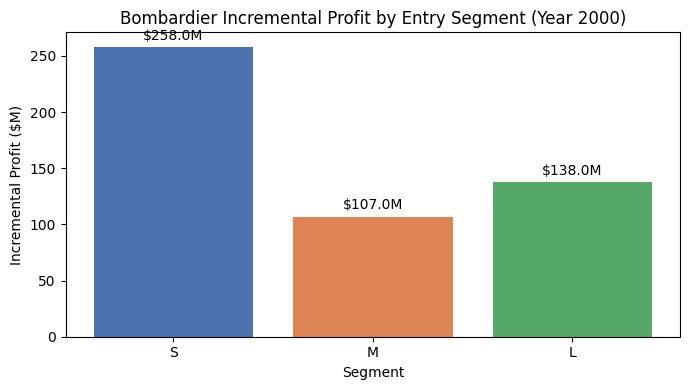

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
segs   = list(bombardier_results.keys())
incrs  = [bombardier_results[s]['incr'] for s in segs]
bars   = ax.bar(segs, incrs, color=['#4C72B0','#DD8452','#55A868'])
ax.bar_label(bars, fmt='${:.1f}M', padding=3)
ax.set(title='Bombardier Incremental Profit by Entry Segment (Year 2000)',
       xlabel='Segment', ylabel='Incremental Profit ($M)')
plt.tight_layout()
plt.show()

### Question 4 — Gulfstream New Product Entry (Year 2000)

We repeat the analysis for Gulfstream. Unlike Bombardier, **Gulfstream only operates in the Large segment** in 2000. Entering S or M is therefore a *greenfield* entry (no existing Gulfstream product to cannibalise), while entering L would add a second Large product alongside the existing one.

In [17]:
print(f'Gulfstream existing segments in 2000: {list(d00[d00.manuf=="Gulfstream"].segment)}')

gulfstream_results = {}
for seg in ['S', 'M', 'L']:
    db_new   = delta_base_new_product(seg, 'Gulfstream', params, d00)
    avg_price= d00[d00.segment == seg]['price'].mean()
    avg_mc   = d00[d00.segment == seg]['mc'].mean()

    new_row = {
        'year': 2000, 'segment': seg, 'manuf': 'Gulfstream_new', 'firm': 'Gulfstream',
        'delta_base': db_new, 'price': avg_price, 'mc': avg_mc,
        'purchases': 0, 'market_size': mkt_size,
        'range': d00[d00.segment==seg]['range'].mean(),
        'vol':   d00[d00.segment==seg]['vol'].mean(),
        'speed': d00[d00.segment==seg]['speed'].mean(),
    }
    d_entry = pd.concat([d00.copy(), pd.DataFrame([new_row])], ignore_index=True)
    d_entry['firm'] = d_entry['manuf'].apply(
        lambda x: 'Gulfstream' if 'Gulfstream' in x else x)
    mc_entry = d_entry['mc'].values

    p_entry, s_entry = solve_equilibrium(
        d_entry, gamma, mc_entry,
        p_init=np.append(p_pre, avg_price))

    fm_entry = np.array(d_entry['firm'].astype(str).tolist())
    fm_pre   = np.array(d00['firm'].astype(str).tolist())
    pi_post  = firm_profit(p_entry, s_entry, mc_entry, fm_entry, 'Gulfstream', mkt_size)
    pi_pre   = firm_profit(p_pre,   s_pre,   mc00,     fm_pre,   'Gulfstream', mkt_size)

    gulfstream_results[seg] = {
        'pi_pre': pi_pre, 'pi_post': pi_post, 'incr': pi_post - pi_pre,
        'new_share': s_entry[-1], 'new_price': p_entry[-1]
    }
    print(f'Seg {seg}: new_price={p_entry[-1]:.2f}  new_share={s_entry[-1]:.5f}  '
          f'incr_profit=${pi_post-pi_pre:.1f}M')

best_seg_gulf = max(gulfstream_results, key=lambda k: gulfstream_results[k]['incr'])
print(f'\n→ Gulfstream should enter Segment {best_seg_gulf} '
      f'(incremental profit ${gulfstream_results[best_seg_gulf]["incr"]:.1f}M)')

Gulfstream existing segments in 2000: ['L']
Seg S: new_price=10.94  new_share=0.00089  incr_profit=$71.9M
Seg M: new_price=22.60  new_share=0.00037  incr_profit=$29.7M
Seg L: new_price=46.24  new_share=0.00047  incr_profit=$38.4M

→ Gulfstream should enter Segment S (incremental profit $71.9M)


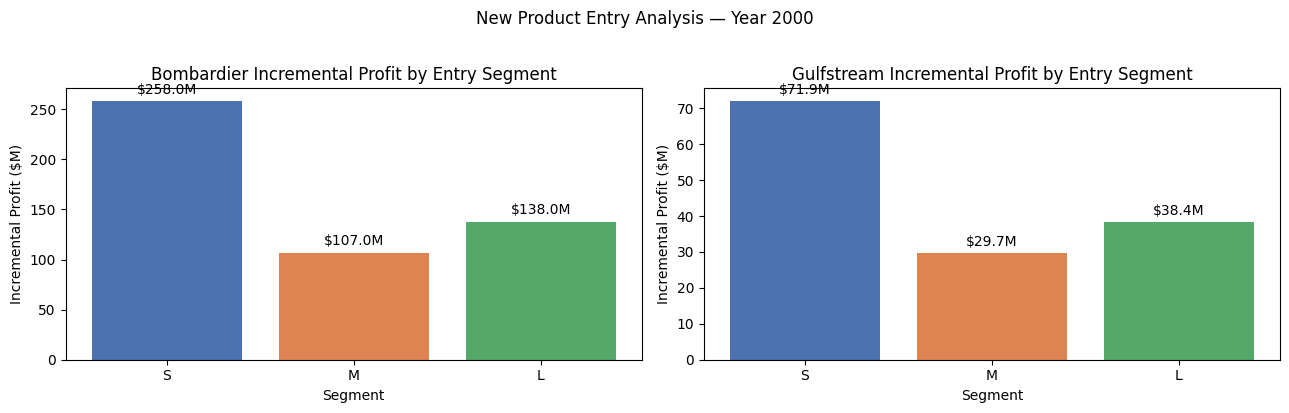

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, res, firm in zip(axes,
                          [bombardier_results, gulfstream_results],
                          ['Bombardier', 'Gulfstream']):
    segs  = list(res.keys())
    incrs = [res[s]['incr'] for s in segs]
    bars  = ax.bar(segs, incrs, color=['#4C72B0','#DD8452','#55A868'])
    ax.bar_label(bars, fmt='${:.1f}M', padding=3)
    ax.set(title=f'{firm} Incremental Profit by Entry Segment',
           xlabel='Segment', ylabel='Incremental Profit ($M)')

plt.suptitle('New Product Entry Analysis — Year 2000', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
print('=== Summary: Firms\' Incentives to Introduce New Products ===')
print()
print(f'Bombardier optimal entry: Segment {best_seg_bomb}')
print(f'  • Already present in all three segments — entry is always a 2nd product')
print(f'  • Segment S has the most active demand and highest multi-product pricing gains')
print(f'  • A second S-product allows the firm to raise prices on its existing S jet')
print()
print(f'Gulfstream optimal entry: Segment {best_seg_gulf}')
print(f'  • Currently only in L — any entry in S or M is greenfield (no cannibalisation)')
print(f'  • Segment S offers the largest new profit stream despite Gulfstream having')
print(f'    no brand recognition there (its fixed effect is the baseline Bombardier level)')
print()
print('Both firms prefer Segment S. This suggests:')
print('  1. The small-jet segment has the deepest unmet demand (large outside share)')
print('  2. Firms face incentives to cluster in the same segment, intensifying competition there')
print('  3. Multi-product firms can use a second product to soften competition (raise umbrella prices)')
print('     rather than to steal share from rivals — a classic business-stealing vs market-expansion tradeoff.')

=== Summary: Firms' Incentives to Introduce New Products ===

Bombardier optimal entry: Segment S
  • Already present in all three segments — entry is always a 2nd product
  • Segment S has the most active demand and highest multi-product pricing gains
  • A second S-product allows the firm to raise prices on its existing S jet

Gulfstream optimal entry: Segment S
  • Currently only in L — any entry in S or M is greenfield (no cannibalisation)
  • Segment S offers the largest new profit stream despite Gulfstream having
    no brand recognition there (its fixed effect is the baseline Bombardier level)

Both firms prefer Segment S. This suggests:
  1. The small-jet segment has the deepest unmet demand (large outside share)
  2. Firms face incentives to cluster in the same segment, intensifying competition there
  3. Multi-product firms can use a second product to soften competition (raise umbrella prices)
     rather than to steal share from rivals — a classic business-stealing vs market